In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
dataset = pd.read_csv('WineQT.csv')
X = dataset.iloc[:, :-2].values
y = dataset.iloc[:, -2].values

In [46]:
y = y.reshape(len(y), 1)
print(y)

[[5]
 [5]
 [5]
 ...
 [5]
 [6]
 [5]]


In [47]:
from sklearn.preprocessing import StandardScaler
st_X = StandardScaler()
st_y = StandardScaler()
X = st_X.fit_transform(X)
y = st_y.fit_transform(y)

In [48]:
print(X)

[[-0.52157961  0.93933222 -1.36502663 ...  1.27069495 -0.57365783
  -0.96338181]
 [-0.29259344  1.94181282 -1.36502663 ... -0.70892755  0.1308811
  -0.59360107]
 [-0.29259344  1.27349242 -1.16156762 ... -0.32577481 -0.04525363
  -0.59360107]
 ...
 [-1.20853813  0.38239855 -0.9581086  ...  0.88754221 -0.45623467
   0.05351522]
 [-1.38027776  0.10393172 -0.8563791  ...  1.33455374  0.60057372
   0.70063152]
 [-1.38027776  0.6330187  -0.75464959 ...  1.65384769  0.30701583
  -0.22382033]]


In [49]:
print(y)

[[-0.81572437]
 [-0.81572437]
 [-0.81572437]
 ...
 [-0.81572437]
 [ 0.42578423]
 [-0.81572437]]


In [50]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 0)

In [51]:
print(X_train)

[[-1.26578467  0.38239855 -0.9581086  ...  0.44053067 -0.69108098
   0.51574115]
 [ 1.42480285 -1.17701572  0.87302251 ... -0.58120997  0.71799688
  -0.4087107 ]
 [ 0.33711853 -0.73146879  0.26264547 ...  0.44053067  0.6592853
   0.05351522]
 ...
 [ 0.85233742 -0.78716215  0.82215776 ... -0.77278634 -1.1607736
   0.88552188]
 [-0.69331924 -0.06314838 -1.21243237 ...  1.20683616 -0.33881152
  -0.59360107]
 [ 0.27987199 -1.12132236  0.72042825 ... -0.07033965 -0.22138836
   1.53263818]]


In [52]:
print(y_train)

[[-0.81572437]
 [ 0.42578423]
 [ 1.66729282]
 [-0.81572437]
 [ 0.42578423]
 [ 0.42578423]
 [ 0.42578423]
 [ 0.42578423]
 [-0.81572437]
 [-0.81572437]
 [ 0.42578423]
 [ 1.66729282]
 [-0.81572437]
 [ 0.42578423]
 [ 0.42578423]
 [ 0.42578423]
 [-0.81572437]
 [ 0.42578423]
 [-0.81572437]
 [ 1.66729282]
 [-0.81572437]
 [ 0.42578423]
 [ 1.66729282]
 [-0.81572437]
 [-0.81572437]
 [ 0.42578423]
 [ 0.42578423]
 [-0.81572437]
 [ 0.42578423]
 [ 0.42578423]
 [-0.81572437]
 [-0.81572437]
 [ 0.42578423]
 [-0.81572437]
 [ 0.42578423]
 [ 0.42578423]
 [ 0.42578423]
 [-0.81572437]
 [-0.81572437]
 [-0.81572437]
 [ 0.42578423]
 [ 0.42578423]
 [-0.81572437]
 [ 0.42578423]
 [-0.81572437]
 [ 0.42578423]
 [-0.81572437]
 [ 1.66729282]
 [-0.81572437]
 [ 1.66729282]
 [ 0.42578423]
 [ 0.42578423]
 [-0.81572437]
 [ 0.42578423]
 [-0.81572437]
 [ 1.66729282]
 [-0.81572437]
 [ 0.42578423]
 [-0.81572437]
 [ 0.42578423]
 [-0.81572437]
 [-0.81572437]
 [-0.81572437]
 [-0.81572437]
 [-0.81572437]
 [ 0.42578423]
 [-3.29874

In [53]:
from sklearn.svm import SVR
regressor = SVR(kernel = 'rbf')
regressor.fit(X_train,y_train)

D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [54]:
st_y.inverse_transform(regressor.predict(st_X.transform([[7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]])).reshape(-1,1))

array([[4.98182924]])

In [60]:
y_train_pred = st_y.inverse_transform((regressor.predict(X_train)).reshape(-1,1))
y_train_actual = st_y.inverse_transform(y_train)


y_test_pred = st_y.inverse_transform((regressor.predict(X_test)).reshape(-1,1))
y_test_actual = st_y.inverse_transform(y_test)

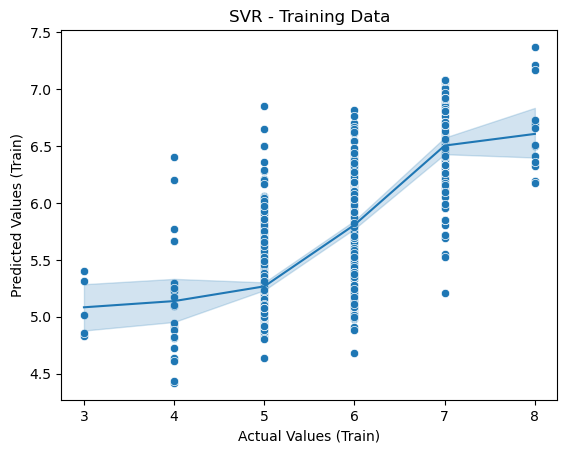

In [64]:
sns.scatterplot(x = y_train_actual.flatten(), y = y_train_pred.flatten())
sns.lineplot(x = y_train_actual.flatten(), y = y_train_pred.flatten())
plt.xlabel("Actual Values (Train)")
plt.ylabel("Predicted Values (Train)")
plt.title("SVR - Training Data")
plt.show()

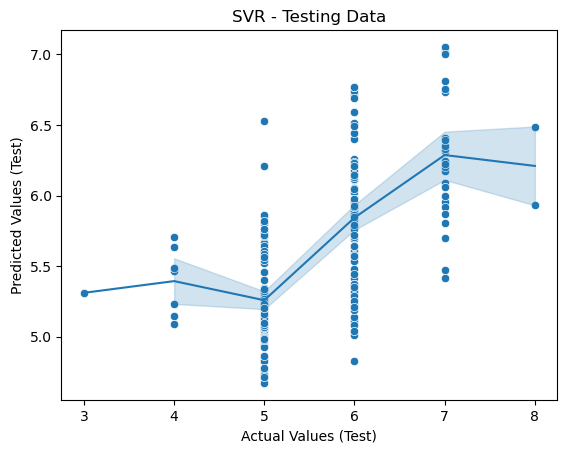

In [67]:
sns.scatterplot(x = y_test_actual.flatten(), y = y_test_pred.flatten())
sns.lineplot(x = y_test_actual.flatten(), y = y_test_pred.flatten())
plt.xlabel("Actual Values (Test)")
plt.ylabel("Predicted Values (Test)")
plt.title("SVR - Testing Data")
plt.show()

In [68]:
# Predict
y_pred = regressor.predict(X_test)

# Convert back to original scale (VERY IMPORTANT for SVR)
y_pred = st_y.inverse_transform(y_pred.reshape(-1,1))
y_test_actual = st_y.inverse_transform(y_test)

# Format output
np.set_printoptions(precision=2)

# Print side-by-side
print(np.concatenate((y_pred, y_test_actual), axis=1))

[[4.94 5.  ]
 [5.23 4.  ]
 [5.01 6.  ]
 [5.55 6.  ]
 [5.21 5.  ]
 [5.87 6.  ]
 [5.59 5.  ]
 [5.99 6.  ]
 [6.16 6.  ]
 [5.7  7.  ]
 [5.16 5.  ]
 [5.54 6.  ]
 [5.11 6.  ]
 [5.71 5.  ]
 [6.11 6.  ]
 [4.83 6.  ]
 [5.87 6.  ]
 [5.7  6.  ]
 [4.93 5.  ]
 [5.26 5.  ]
 [6.14 6.  ]
 [4.87 5.  ]
 [5.47 7.  ]
 [5.58 6.  ]
 [5.13 5.  ]
 [5.81 5.  ]
 [5.58 5.  ]
 [5.99 6.  ]
 [5.85 6.  ]
 [5.46 5.  ]
 [5.08 6.  ]
 [5.08 5.  ]
 [5.85 5.  ]
 [6.52 6.  ]
 [5.6  5.  ]
 [5.69 6.  ]
 [5.42 6.  ]
 [5.64 4.  ]
 [5.07 5.  ]
 [5.89 6.  ]
 [5.3  5.  ]
 [6.15 6.  ]
 [5.37 6.  ]
 [6.12 6.  ]
 [5.07 5.  ]
 [5.27 5.  ]
 [5.08 5.  ]
 [6.31 7.  ]
 [5.93 8.  ]
 [5.85 6.  ]
 [5.32 6.  ]
 [5.24 5.  ]
 [5.05 5.  ]
 [7.05 7.  ]
 [5.52 5.  ]
 [5.29 5.  ]
 [5.4  5.  ]
 [5.05 5.  ]
 [5.3  5.  ]
 [5.83 6.  ]
 [5.59 6.  ]
 [4.83 5.  ]
 [6.15 6.  ]
 [5.24 5.  ]
 [5.3  6.  ]
 [5.08 5.  ]
 [6.18 6.  ]
 [5.06 5.  ]
 [5.86 5.  ]
 [5.81 7.  ]
 [4.97 5.  ]
 [5.22 5.  ]
 [5.57 6.  ]
 [6.33 7.  ]
 [6.21 6.  ]
 [6.18 7.  ]
 [6.26 6.  ]